데이터 셋이 완성이 될 때까지 기다릴 수 없는 상황에서 점진적으로 들어오는 데이터를 학습 시키는 알고리즘.

In [28]:
import pandas as pd 
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [29]:
print(fish.head())

  Species  Weight  Length  Diagonal   Height   Width
0   Bream   242.0    25.4      30.0  11.5200  4.0200
1   Bream   290.0    26.3      31.2  12.4800  4.3056
2   Bream   340.0    26.5      31.1  12.3778  4.6961
3   Bream   363.0    29.0      33.5  12.7300  4.4555
4   Bream   430.0    29.0      34.0  12.4440  5.1340


In [30]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']


In [31]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state= 42)


In [32]:
import sklearn
sklearn.set_config(display = 'text')



In [33]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)


In [34]:
from sklearn.linear_model import SGDClassifier



In [35]:
sc = SGDClassifier(loss = 'log_loss', max_iter =10, random_state=42)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))


0.7815126050420168
0.8


c:\Users\sdj03\Macine_Learning\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## 모델이 학습이 된 상태에서 추가 학습을 진행할 수 있음. 

추가 학습을 할 때는 
```partial_fit()```

함수를 이용해서 구현한다. 

In [37]:
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))



0.7983193277310925
0.825


In [38]:
import numpy as np
sc = SGDClassifier(loss = 'log_loss', random_state= 42)
train_score = []
test_score = []
classes = np.unique(train_target)


In [39]:
for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes= classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))
    





Text(0, 0.5, 'accuracy')

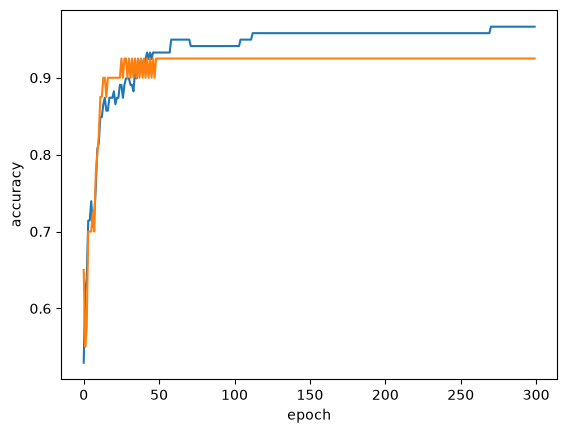

In [42]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')

In [43]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925
